<a href="https://colab.research.google.com/github/TAUforPython/LLM_AI_agents/blob/main/lesson-3_simple_agent_Langchain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# My First Medical Agent


1. About The Agent We Will Build Throughout the Intensive
1.1 What is τ²-bench (Adapted for Medical)
Recent benchmarks have been proposed to evaluate LLM agents that interact with users, tools, and real-world systems.
In this medical context, imagine a benchmark evaluating agents interacting within a hospital or clinic environment.

Let's call our adapted benchmark **MedBench**.
MedBench evaluates agents that must:
- converse with patients or healthcare staff
- use tools/APIs (e.g., patient records, medication lookup, appointment scheduler)
- follow domain-specific rules (e.g., medical protocols, privacy policies, scheduling constraints)

It simulates realistic healthcare scenarios such as patient check-in, symptom checking, appointment scheduling, or requesting medical records.
τ²-bench extends this setup to a dual-control environment, where both the agent and the user can take actions via tools, making interactions more realistic.
Papers (Conceptual for Medical Context)
- Original τ-bench: A Benchmark for Tool-Agent-User Interaction in Real-World Domains [https://arxiv.org/abs/2406.12045]
- Original τ²-Bench: Evaluating Conversational Agents in a Dual-Control Environment [https://arxiv.org/abs/2506.07982]

GitHub Repositories (Conceptual)
- Original τ-bench: https://github.com/sierra-research/tau-bench
- Original τ²-bench: https://github.com/sierra-research/tau2-bench

In [3]:
import json
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, TypedDict

## 1.2. Medical Assistant Agent - Task Overview
We will implement an agent for the medical domain — a patient support assistant.
The agent must:
- understand the patient's inquiry or symptoms
- gather missing information if required
- potentially search for appointments or general policy information via simulated tools/APIs (not implemented in this basic version)
- respect medical privacy rules, appointment policies, and triage guidelines
- guide the patient appropriately (e.g., schedule appointment, provide policy info, advise seeking immediate care)
This scenario captures many core challenges of real-world AI agents: multi-turn dialogue, planning, tool use, and rule following.


In [4]:

# Using a local directory to simulate the data structure
MED_DOMAIN_DIR = Path("data/medbench/domains/medical")

# Create the directory structure and policy file locally in Colab for simulation
MED_DOMAIN_DIR.mkdir(parents=True, exist_ok=True)
policy_content = """
# Medical Practice Policy

## Patient Privacy
- All patient information is strictly confidential.
- The agent cannot access or disclose specific medical records.
- Always ask for explicit consent before discussing health details.

## Appointment Scheduling
- Routine appointments require advance notice (e.g., 24-48 hours).
- Urgent care slots are limited and reserved for true emergencies.
- Patients must confirm their appointment details provided by the system (when tools are available).

## Triage Guidelines
- For life-threatening symptoms (e.g., chest pain, severe difficulty breathing, signs of stroke), immediately advise calling emergency services (911).
- For minor symptoms, suggest scheduling a routine appointment or visiting a walk-in clinic.
- For prescription refills, direct the patient to contact their doctor or pharmacy directly (not handled by this basic agent).
"""
(MED_DOMAIN_DIR / "policy.md").write_text(policy_content)

886

In [5]:
# Simulate a tasks.json file
tasks_data_simulated = [
    {
        "task_id": "med_task_001",
        "user_scenario": {
            "instructions": {
                "reason_for_call": "I need to schedule a routine check-up for my annual physical."
            }
        },
        "initial_state": {}
    },
    {
        "task_id": "med_task_002",
        "user_scenario": {
            "instructions": {
                "reason_for_call": "I have a terrible headache and feel dizzy. What should I do?"
            }
        },
        "initial_state": {}
    },
    {
        "task_id": "med_task_003",
        "user_scenario": {
            "instructions": {
                "reason_for_call": "I need to know my test results from last week."
            }
        },
        "initial_state": {}
    }
]

tasks_path_simulated = MED_DOMAIN_DIR / "tasks.json"
with open(tasks_path_simulated, 'w') as f:
    json.dump(tasks_data_simulated, f, indent=2)

from IPython.display import Markdown, display
display(Markdown((MED_DOMAIN_DIR / "policy.md").read_text()))

with open(tasks_path_simulated, "r") as f:
    tasks_data_loaded = json.load(f)

print('Test case example')
print(json.dumps(tasks_data_loaded[0], indent=2))

for i, task in enumerate(tasks_data_loaded[:3]):
    try:
        reason = task["user_scenario"]["instructions"]["reason_for_call"]
    except KeyError:
        reason = None
    print(f"{i}: {reason}\n")
    print("----------------")



# Medical Practice Policy

## Patient Privacy
- All patient information is strictly confidential.
- The agent cannot access or disclose specific medical records.
- Always ask for explicit consent before discussing health details.

## Appointment Scheduling
- Routine appointments require advance notice (e.g., 24-48 hours).
- Urgent care slots are limited and reserved for true emergencies.
- Patients must confirm their appointment details provided by the system (when tools are available).

## Triage Guidelines
- For life-threatening symptoms (e.g., chest pain, severe difficulty breathing, signs of stroke), immediately advise calling emergency services (911).
- For minor symptoms, suggest scheduling a routine appointment or visiting a walk-in clinic.
- For prescription refills, direct the patient to contact their doctor or pharmacy directly (not handled by this basic agent).


Test case example
{
  "task_id": "med_task_001",
  "user_scenario": {
    "instructions": {
      "reason_for_call": "I need to schedule a routine check-up for my annual physical."
    }
  },
  "initial_state": {}
}
0: I need to schedule a routine check-up for my annual physical.

----------------
1: I have a terrible headache and feel dizzy. What should I do?

----------------
2: I need to know my test results from last week.

----------------


## 1.3. How we will work on the agent (Medical Context)

In [2]:
MED_SYSTEM_PROMPT = """
You are a virtual medical assistant for a general practice clinic.
IMPORTANT: In this lesson you have NO tools, NO database access, NO RAG for patient records.
You must be transparent about limitations:
- You cannot look up patient records, specific test results, previous appointments, or prescription details.
- You cannot diagnose conditions definitively or prescribe medication.
- You cannot access real-time availability of doctors.

You can only: explain the clinic's policy, ask clarifying questions about symptoms for potential triage guidance, outline what info is needed to schedule an appointment, and advise on seeking immediate care for emergencies.
Do NOT invent patient details, diagnosis, test results, or doctor availability.
Do NOT provide definitive medical advice beyond general policy or basic triage hints based on clear protocols.
"""

## 2. Lang* ecosystem for agents

We will work with Lang* ecosystem.
What we need now:
* LangChain — a framework for building LLM applications.
Provides abstractions for prompts, chains, tools, agents, memory, retrieval, etc. Use it for simple LLM apps
* LangGraph — an extension for building agents as state machines (graphs).  Gives precise control over multi-step workflows, tool use, loops, branching, and memory.  
Use it for real agent with tools/workflow:
* LangFlow — visual builder (no/low-code UI) for LangChain pipelines and agents.
* LangSmith — debugging, tracing, evaluation, monitoring for LLM apps.

In [9]:
# Install necessary packages
!pip install -q langchain langgraph langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 2.7 MB/s eta 0:00:00


## 2.1. LLM wrapper `langchain_openai.ChatOpenAI` — a wrapper around OpenAI chat models.

In [10]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [12]:
from langchain_openai import ChatOpenAI
MODEL = "gpt-5-nano" # Using gpt-4o-mini as gpt-5-nano might not exist
llm = ChatOpenAI(
    model=MODEL,
    temperature=0.2,
)

"""
`langchain_core.messages` — defines message types used by chat models:
SystemMessage — instructions for the model (policy, role)
HumanMessage — user input
AIMessage — model output
BaseMessage — parent type for all messages
"""
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage


## 2.2. LangGraph details (Medical Context)

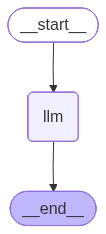

In [14]:
"""
Instead of a simple pipeline (user → LLM → answer), we define a graph where `state` flows through `nodes`. This is how production agents are built, because it allows adding tools, memory, retrieval, and multi-step reasoning later.
2.5.1 Agent State
We define the agent’s state as a typed structure containing the conversation history. The state stores the messages exchanged so far. More advanced agents may also store tool outputs, retrieved documents, user profiles, plans, or intermediate reasoning.
"""
class MedAgentState(TypedDict):
    messages: List[BaseMessage]


"""
### 2.5.2. Nodes
A node is a function that:
Receives the current state
Performs computation
Returns an updated state
Our LLM node:
Prepends the system prompt (agent policy)
Calls the LLM with the conversation history
Appends the model’s reply back into the state
This is how the conversation grows over time.
"""
def med_llm_node(state: MedAgentState) -> MedAgentState:
    msgs = [SystemMessage(content=MED_SYSTEM_PROMPT)] + state["messages"]
    resp = llm.invoke(msgs)
    return {"messages": state["messages"] + [resp]}


"""
### Agent as a StateGraph
We construct a graph where:
nodes are functions
edges define transitions
state flows between nodes
Right now the graph is:
START → LLM → END
So this is a single-step agent. Later we will extend it to multi-step flows like:
LLM → Tool → LLM → Memory → ...
1) Entry point and edges
The entry point defines where execution starts (the LLM node). The edge to END means that after one LLM step, the agent stops.
"""
from langgraph.graph import StateGraph, END
med_graph = StateGraph(MedAgentState)
med_graph.add_node("llm", med_llm_node)
med_graph.set_entry_point("llm")
med_graph.add_edge("llm", END)
med_graph


"""
#### 2) Compile
Compilation transforms the graph definition into an executable program that can be invoked with an initial state.
"""
med_app = med_graph.compile()
med_app


In [15]:


"""
3) Running one interaction
The helper function:
Creates the initial state with a user message
Runs the graph
Returns the model’s reply
"""
def ask_medical_question(user_text: str):
    state = {"messages": [HumanMessage(content=user_text)]}
    out = med_app.invoke(state)
    return out["messages"][-1].content


"""
### Key demonstration
Examples of what the LLM-only medical agent can/cannot do.
"""
# ✅ 2 questions the LLM-only agent CAN answer (policy/constraints reasoning)
MED_CAN_ANSWER = [
    "1) According to the policy, what should I do if I have a life-threatening emergency?",
    "2) Can you tell me the clinic's policy on patient privacy regarding this conversation?",
]

# ❌ 2 questions from your simulated benchmark examples that the LLM-only agent CANNOT solve without tools/DB
MED_CANNOT_ANSWER = [
    "1) Can you look up my last cholesterol test results?",
    "2) I need a refill on my medication prescribed by Dr. Smith.",
]

print("=== LLM-only Medical Agent Demo ===\n")
print("---- CAN answer (policy-based) ----")
for q in MED_CAN_ANSWER:
    print(f"\nPATIENT: {q}")
    print(f"AGENT: {ask_medical_question(q)}")
    print("\n\n---- CANNOT answer (needs tools/DB) ----")
    for q in MED_CANNOT_ANSWER:
        print(f"\nPATIENT: {q}")
        print(f"AGENT: {ask_medical_question(q)}")

"""
### Key takeaway (Medical Context)
This agent:
- has an LLM
- has no tools
- has no database access to patient records
- has no external knowledge beyond its training and the system prompt
- cannot perform actions like looking up records or scheduling
It can only:
- follow the clinic's policy
- explain rules (like privacy, scheduling windows)
- ask clarifying questions about symptoms
- provide general triage guidance based on policy
"""

=== LLM-only Medical Agent Demo ===

---- CAN answer (policy-based) ----

PATIENT: 1) According to the policy, what should I do if I have a life-threatening emergency?
AGENT: If you have a life-threatening emergency, you should seek immediate help by calling your local emergency number right away and not wait for a clinic or triage.

- In the United States or Canada: dial 911.
- In the United Kingdom or Ireland: dial 999.
- In the European Union: dial 112.
- In other locations: use your local emergency number.

While you wait for help:
- If you can do so safely, go to the nearest emergency department or have someone take you there.
- Stay on the line with the dispatcher and provide your location and a brief description of the emergency.
- If you are trained, perform appropriate life-support actions (for example, CPR if someone is unresponsive and not breathing) and follow any dispatcher instructions.
- Do not delay medical care for time-sensitive emergencies.

If you’d like, tell me yo

"\n### Key takeaway (Medical Context)\nThis agent:\n- has an LLM\n- has no tools\n- has no database access to patient records\n- has no external knowledge beyond its training and the system prompt\n- cannot perform actions like looking up records or scheduling\nIt can only:\n- follow the clinic's policy\n- explain rules (like privacy, scheduling windows)\n- ask clarifying questions about symptoms\n- provide general triage guidance based on policy\n"

This part of the code demonstrates the limitations of the very first, simplest version of the agent being built – the one that only uses a Large Language Model (LLM) and nothing else (no tools, no access to databases, no Retrieval-Augmented Generation (RAG) for specific documents).
The key idea is to show the difference between:
Tasks relying on general knowledge or rules: These can sometimes be handled by the LLM if the information was part of its training data (like explaining a general policy provided in the system prompt).
Tasks requiring specific, real-time, or user-specific data: These cannot be handled by the LLM alone.